# EDA — NeoRisk: Predicción Temprana de Sepsis Neonatal

**Bloque 3 (Micro-proyecto, Entrega 1):** exploración general — nulos y distribuciones.

Dataset: *Dataset on neonatal and maternal factors influencing neurodevelopmental
outcomes in preterm infants* (Darabi et al., 2024, Mendeley Data / Data in Brief,
CC BY). Cohorte retrospectiva de 89 neonatos prematuros, Hospital Ghaem, Mashhad,
Irán (2016–2020).

Este notebook cubre:
1. Carga y etiquetado de datos
2. Análisis de nulos
3. Distribuciones univariadas (categóricas y continuas)
4. Distribución de la variable objetivo (`sepsis`)
5. Export a `data/processed/` para los siguientes bloques


In [17]:
import sys
sys.path.append("..")

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.data.loader import (
    CONTINUOUS_VARS,
    FLAGGED_INCONSISTENT_VARS,
    INTERVENTION_VARS,
    MATERNAL_VARS,
    NEONATAL_COMPLICATION_VARS,
    NEURODEV_DOMAIN_VARS,
    TARGET,
    load_labeled,
    load_raw,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)


## 1. Carga de datos

Se usa `load_labeled()` (definido en `src/data/loader.py`) para trabajar con
etiquetas legibles (`yes`/`no`, `male`/`female`, etc.) en vez de códigos
numéricos de SPSS. Para los cálculos de nulos y estadísticas continuas se usa
el DataFrame crudo (`load_raw`), ya que preserva `NaN` de forma más directa.


In [18]:
df_raw, value_labels = load_raw()
df = load_labeled()

print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")
df.head()


Filas: 89, Columnas: 53


/home/afromerogr/Documents/MAIA/desarrolo_de_soluciones/microproyecto/src/data/loader.py:101: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_labeled[col] = df_labeled[col].map(mapping).fillna(df_labeled[col])


,number,Sex,DM,preeclampsia,hypothyroid,PROM,IUGR,pregnancycomplication,pneumothorax,NEC,sepsis,PDA,icter,meningitis,IVH,seizure,BPD,apgar1,apgar5,B.C,PregnancyAge,drug.mother,duration.hopitalization,laborType,type.of.ressucitation,ehya.badve.tavallod,BirthWeight,RoundHeadAtBirth,surfactant,aggressive.ventilation,notaggressive.ventilation,csf.culture,congenital.anomaly,duration.O2,SepsisnegativeCulture,mother.sonogarphy.result,CognitiveDomain,LanguageDomain,PerceptualDomain,finemotor,coarsemotor,correctedage,Age,lang.recode,percep.recode,fine.recode,coarse.recode,cog.recode,lang.cat,percep.cat,fine.cat,cog.cat,coarse.cat
0,13.0,female,no,no,no,yes,YES,yes,yes,no,yes,yes,no,no,no,no,yes,5.0,6.0,positive,26.0,no,58.0,NVD,advanced,yes,670.5,25.0,yes,yes,yes,Negatiev,no,24.0,yes,normal,< -2 sd,< -2 sd,< -1 sd,< -2 sd,< - 2 sd,1190.0,1190.0,< - 2 sd,< -1 sd,< - 2 sd,< - 2 sd,< - 2 sd,abnormal,abnormal,abnormal,abnormal,abnormal
1,21.0,male,no,yes,no,no,NO,yes,no,no,yes,no,yes,no,no,no,no,6.0,8.0,positive,33.0,yes,26.0,cs,NaN,NO,1910.0,31.5,no,no,yes,Negatiev,no,2.0,no,normal,n,< -1 sd,n,n,n,1170.0,1170.0,< -1 sd,Normal,Normal,Normal,Normal,abnormal,normal,normal,normal,normal
2,28.0,female,no,no,no,yes,NO,yes,no,no,no,no,yes,no,yes,no,no,7.0,8.0,negative,29.0,no,42.0,NVD,ppv,yes,1150.0,27.0,yes,yes,yes,Negatiev,no,17.0,yes,normal,< -2 sd,< -1 sd,< -1 sd,< -1 sd,< -1 sd,1167.0,1167.0,< -1 sd,< -1 sd,< -1 sd,< -1 sd,< - 2 sd,abnormal,abnormal,abnormal,abnormal,abnormal
3,15.0,female,no,no,no,no,YES,no,no,no,no,no,yes,no,no,no,no,8.0,8.0,negative,34.0,no,2.0,NVD,NaN,NO,1650.0,32.0,no,no,yes,Negatiev,no,1.0,no,normal,< -2 sd,< -2 sd,< -2 sd,< -1 sd,< -1 sd,1123.0,1123.0,< - 2 sd,< - 2 sd,< -1 sd,< -1 sd,< - 2 sd,abnormal,abnormal,abnormal,abnormal,abnormal
4,30.0,female,yes,no,no,yes,NO,yes,no,no,no,no,yes,no,no,no,no,8.0,9.0,negative,32.0,yes,13.0,NVD,NaN,NO,1650.0,32.0,no,no,yes,Negatiev,no,1.0,no,normal,n,n,n,n,n,1123.0,1123.0,Normal,Normal,Normal,Normal,Normal,normal,normal,normal,normal,normal


## 2. Análisis de nulos

Se cuantifica el porcentaje de valores faltantes por columna. Solo 3 variables
tienen nulos en este dataset; se documentan explícitamente para decidir cómo
tratarlas en el pipeline de features (Bloque 4 en adelante).


In [19]:
null_summary = (
    df_raw.isnull()
    .sum()
    .to_frame("n_nulls")
    .assign(pct_nulls=lambda x: (x["n_nulls"] / len(df_raw) * 100).round(1))
    .query("n_nulls > 0")
    .sort_values("n_nulls", ascending=False)
)
null_summary


,n_nulls,pct_nulls
type.of.ressucitation,59,66.3
correctedage,4,4.5
Age,2,2.2


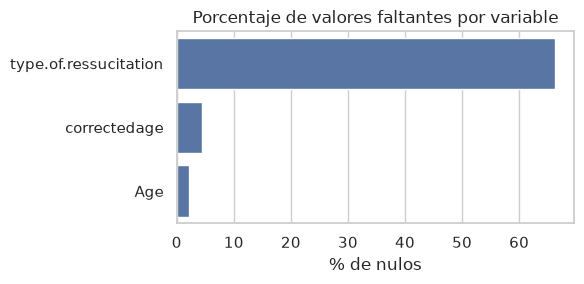

In [20]:
fig, ax = plt.subplots(figsize=(6, 3))
sns.barplot(
    data=null_summary.reset_index().rename(columns={"index": "variable"}),
    x="pct_nulls", y="variable", ax=ax, color="#4C72B0"
)
ax.set_xlabel("% de nulos")
ax.set_ylabel("")
ax.set_title("Porcentaje de valores faltantes por variable")
plt.tight_layout()
plt.show()


**Hallazgos:**

- `type.of.ressucitation` tiene **66% de nulos** (59/89) — es probable que el
  faltante no sea aleatorio (solo se registra si hubo reanimación). Candidato
  a tratarse como categoría propia (`"no_resuscitation"`) en vez de imputarse,
  pendiente de confirmar con criterio del equipo.
- `correctedage` (4 nulos) y `Age` (2 nulos): nulos menores, pero **ver nota
  de calidad de datos más abajo** — sus valores no calzan con lo que describe
  el codebook.


###  Nota de calidad de datos: `correctedage` / `Age`

El codebook las describe como variables ordinales (1 = `< -1 sd`, 2 = `< -2 sd`,
3 = `Normal`), pero los valores observados son enteros grandes (decenas a
más de mil), consistentes con **edad en días** y no con una escala ordinal.
Se deja documentado aquí; no se usan estas dos columnas en este notebook hasta
que el equipo confirme su significado real contra la fuente original.


In [21]:
df_raw[FLAGGED_INCONSISTENT_VARS].describe()


,correctedage,Age
count,85.000000,87.000000
mean,560.670588,622.770115
std,301.413274,296.460386
min,66.000000,130.000000
25%,392.000000,430.500000
50%,494.000000,575.000000
75%,820.000000,844.500000
max,1190.000000,1190.000000


## 3. Distribuciones univariadas — variables continuas

Variables antropométricas y clínicas de ingreso: edad gestacional, peso al
nacer, Apgar, duración de hospitalización, duración de oxígeno suplementario,
perímetro cefálico.


In [22]:
df_raw[CONTINUOUS_VARS].describe().T


,count,mean,std,min,25%,50%,75%,max
PregnancyAge,89.0,32.106742,1.907628,26.0,31.0,32.0,34.0,34.5
BirthWeight,89.0,1631.297753,446.162264,670.5,1320.0,1650.0,1900.0,2650.0
apgar1,89.0,7.089888,1.957738,1.0,6.0,8.0,8.0,9.0
apgar5,89.0,8.640449,1.367207,3.0,8.0,9.0,10.0,10.0
duration.hopitalization,89.0,19.011236,15.046515,1.0,8.0,14.0,29.0,62.0
duration.O2,89.0,6.325843,10.264430,0.0,0.0,1.0,7.0,54.0
RoundHeadAtBirth,89.0,29.579775,2.869399,21.0,27.5,30.0,32.0,34.5


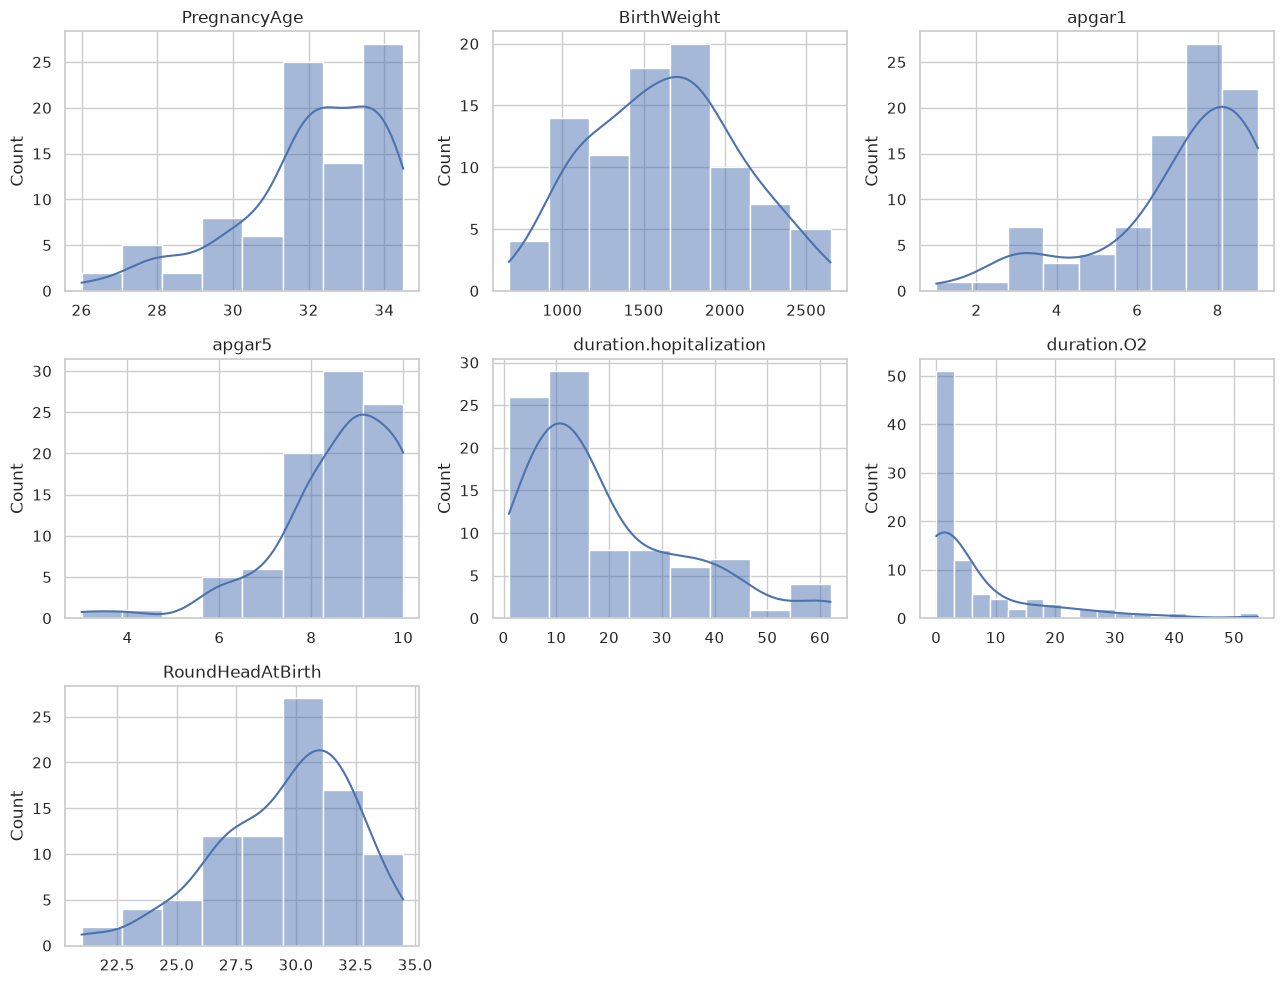

In [23]:
fig, axes = plt.subplots(3, 3, figsize=(13, 10))
axes = axes.flatten()

for i, col in enumerate(CONTINUOUS_VARS):
    sns.histplot(df_raw[col].dropna(), kde=True, ax=axes[i], color="#4C72B0")
    axes[i].set_title(col)
    axes[i].set_xlabel("")

for j in range(len(CONTINUOUS_VARS), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


## 4. Distribuciones univariadas — variables categóricas

Agrupadas en tres bloques temáticos definidos en el codebook: condiciones
maternas/gestacionales, complicaciones neonatales, e intervenciones médicas.


In [24]:
def plot_categorical_group(df, cols, title, ncols=4):
    nrows = -(-len(cols) // ncols)  # ceil division
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
    axes = axes.flatten()

    for i, col in enumerate(cols):
        counts = df[col].value_counts(dropna=False)
        sns.barplot(x=counts.index.astype(str), y=counts.values, ax=axes[i], color="#55A868")
        axes[i].set_title(col, fontsize=10)
        axes[i].tick_params(axis="x", rotation=30)
        axes[i].set_ylabel("")

    for j in range(len(cols), len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()


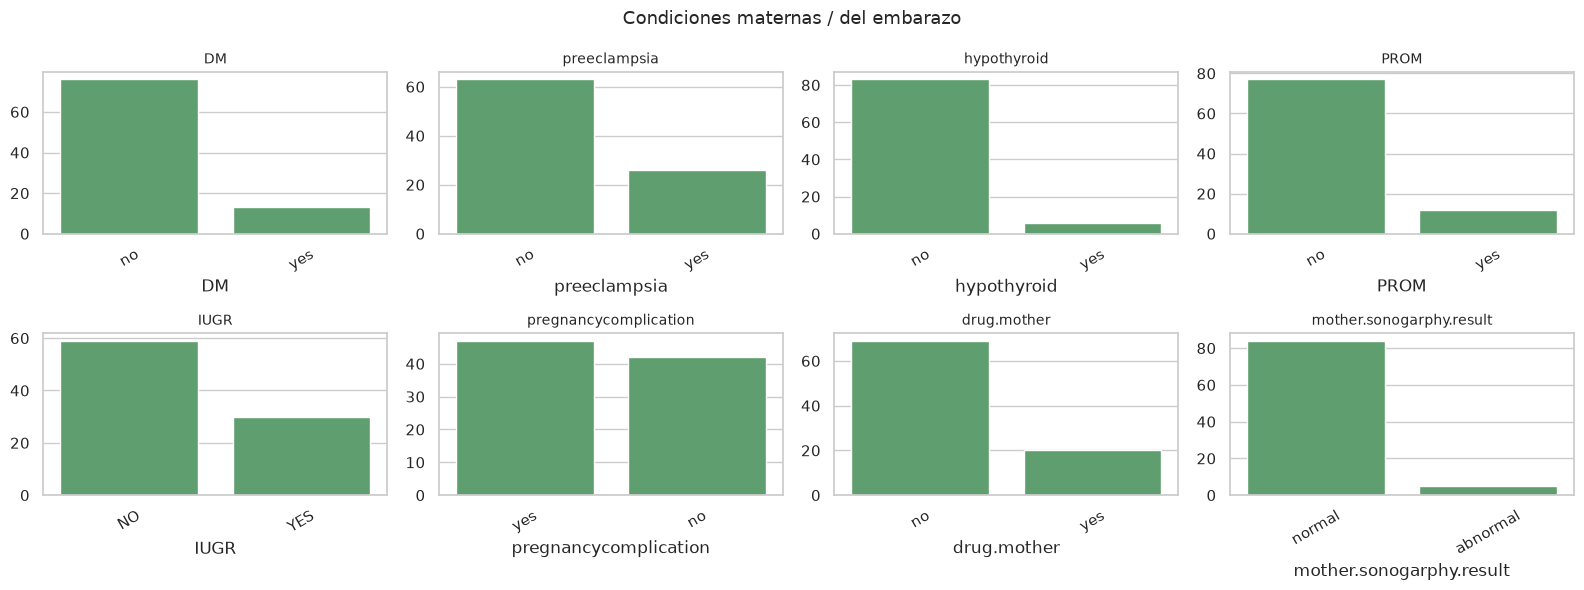

In [25]:
plot_categorical_group(df, MATERNAL_VARS, "Condiciones maternas / del embarazo")


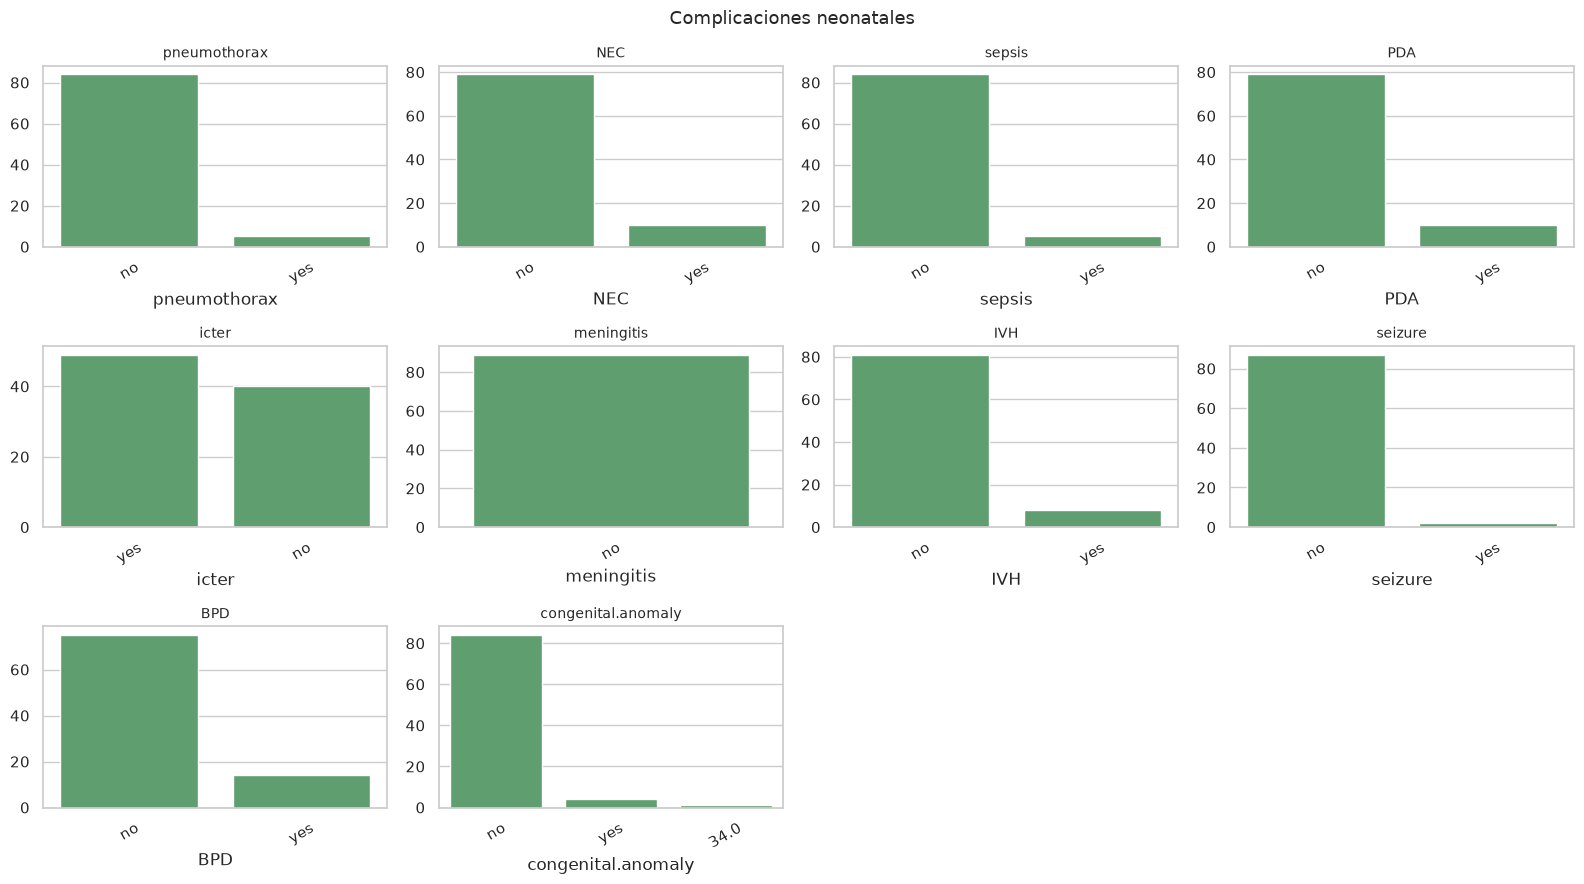

In [26]:
plot_categorical_group(df, NEONATAL_COMPLICATION_VARS, "Complicaciones neonatales")


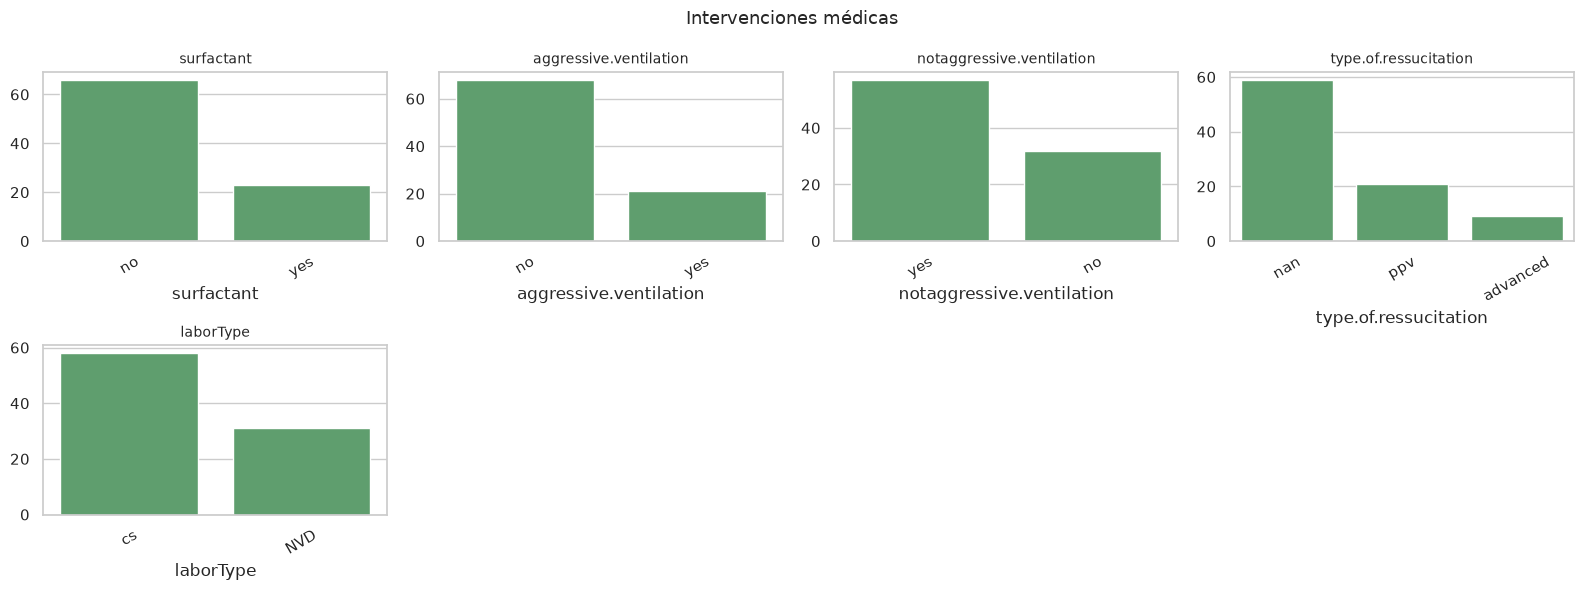

In [27]:
plot_categorical_group(df, INTERVENTION_VARS, "Intervenciones médicas")


## 5. Variable objetivo: `sepsis`

Distribución de la variable target del problema de negocio.


sepsis
no     84
yes     5
Name: count, dtype: int64

sepsis
no     94.4%
yes     5.6%
Name: count, dtype: object


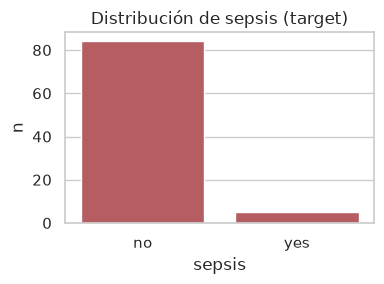

In [28]:
target_counts = df[TARGET].value_counts(dropna=False)
target_pct = (target_counts / len(df) * 100).round(1)

print(target_counts)
print()
print(target_pct.astype(str) + "%")

fig, ax = plt.subplots(figsize=(4, 3))
sns.barplot(x=target_counts.index.astype(str), y=target_counts.values, ax=ax, color="#C44E52")
ax.set_title("Distribución de sepsis (target)")
ax.set_ylabel("n")
plt.tight_layout()
plt.show()


**Hallazgo crítico — desbalance de clases:**

Solo **5 de 89 casos (5.6%)** son positivos para sepsis. Con un dataset de
este tamaño, esto deja ~4 casos positivos si se hace un split train/test
estándar (80/20), lo cual es insuficiente para entrenar y validar un
clasificador de forma confiable.

**Implicaciones a discutir con el equipo antes de Bloque 4:**
- Evaluar si vale la pena usar `SepsisnegativeCulture` o `B.C` (hemocultivo)
  como variables relacionadas/proxy, o si conviene revisar el problema
  alternativo (retraso en desarrollo cognitivo/motor — dominios con clases
  más balanceadas, ver `*.cat` columns).
- Si se mantiene sepsis como target: usar métricas robustas a desbalance
  (recall, F1, PR-AUC en vez de accuracy), y considerar `class_weight` o
  técnicas de remuestreo (con mucha cautela dado el n tan pequeño).


In [29]:
# Distribución de las variables *.cat (dominios de neurodesarrollo) —
# referencia rápida por si el equipo decide revisar el problema alternativo.
cat_vars = ["cog.cat", "lang.cat", "percep.cat", "fine.cat", "coarse.cat"]
for col in cat_vars:
    print(df[col].value_counts(dropna=False), "\n")


cog.cat
normal      62
abnormal    27
Name: count, dtype: int64 

lang.cat
normal      61
abnormal    28
Name: count, dtype: int64 

percep.cat
normal      58
abnormal    31
Name: count, dtype: int64 

fine.cat
normal      67
abnormal    22
Name: count, dtype: int64 

coarse.cat
normal      67
abnormal    22
Name: count, dtype: int64 



## 6. Export a `data/processed/`

Se guarda el DataFrame etiquetado para que los siguientes bloques (EDA
enfocado / correlaciones, features, modelado) partan de la misma base.


In [30]:
import os

os.makedirs("../data/processed", exist_ok=True)
df.to_csv("../data/processed/preterm_infant_labeled.csv", index=False)
print("Guardado en data/processed/preterm_infant_labeled.csv")


Guardado en data/processed/preterm_infant_labeled.csv


## 7. Correlación entre dominios de neurodesarrollo

Análisis adicional: correlación entre los cinco dominios evaluados por las Escalas Bayley,
relevante para la definición de la variable objetivo compuesta (Sección 5).

/tmp/ipykernel_19837/2972871485.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  domain_numeric = df[domain_vars].replace({"abnormal": 1, "normal": 0})


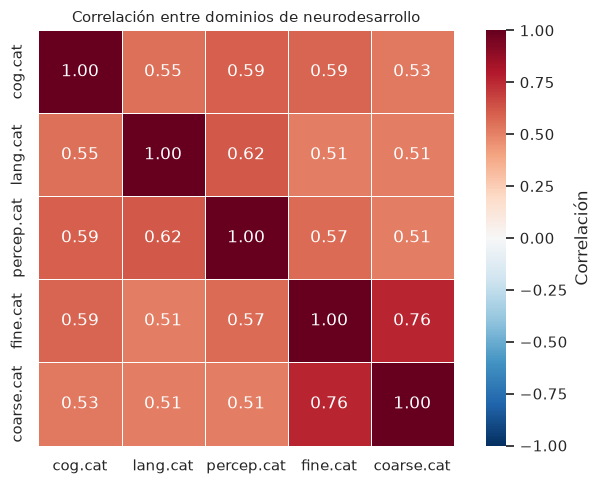

In [31]:
domain_vars = ["cog.cat", "lang.cat", "percep.cat", "fine.cat", "coarse.cat"]

domain_numeric = df[domain_vars].replace({"abnormal": 1, "normal": 0})
corr_matrix = domain_numeric.corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Correlación"},
    ax=ax,
)
ax.set_title("Correlación entre dominios de neurodesarrollo", fontsize=11)
plt.tight_layout()
plt.show()

In [32]:
agreement = (df["fine.cat"] == df["coarse.cat"]).mean()
print(f"Acuerdo fine.cat vs coarse.cat: {agreement*100:.1f}%")

Acuerdo fine.cat vs coarse.cat: 91.0%


## Resumen de hallazgos (para el reporte)

- **n = 89** neonatos prematuros, 53 variables.
- Nulos concentrados en 3 columnas; `type.of.ressucitation` con 66% de
  faltantes (probablemente no aleatorio — solo aplica si hubo reanimación).
- `correctedage` y `Age` presentan inconsistencia entre el codebook y los
  valores reales (posible edad en días, no escala ordinal) — pendiente de
  confirmación antes de usarlas.
- **Target `sepsis` con desbalance severo (5.6% positivos)** — riesgo
  importante para la viabilidad del modelo supervisado tal como está
  planteado; requiere decisión de equipo.
- Variables continuas (edad gestacional, peso al nacer, Apgar, etc.) sin
  valores atípicos evidentes a simple vista; distribución razonable para
  una cohorte de prematuros.
